In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
pd.set_option('display.max_columns', None)

In [3]:
transactions = pd.read_csv("finance_transactions.csv")
customers = pd.read_csv("customers.csv")

print(transactions.shape)
print(customers.shape)

(50069, 15)
(5000, 11)


In [4]:
transactions.head()

,transaction_id,transaction_date,account_id,customer_id,transaction_type,channel,merchant_category,amount,fee_amount,tax_amount,currency,transaction_status,is_fraud,risk_score,reference_no
0,T00000001,21-02-2025,A001795,C00629,Investment,Mobile App,Food Delivery,24721.24,123.61,22.25,INR,Success,No,63,REF8835851139
1,T00000002,28-01-2023,A004859,C02038,Transfer,UPI,Groceries,18711.77,93.56,16.84,INR,Success,No,21,REF9409811139
2,T00000003,25-06-2024,A003081,C00652,Transfer,Net Banking,Groceries,45865.90,0.00,0.00,INR,Success,No,25,REF1704628312
3,T00000004,20-02-2025,A004122,C01357,Withdrawal,Auto Debit,Salary,4310.91,NaN,0.78,INR,Failed,No,43,REF3937614748
4,T00000005,08-06-2024,A004150,C02547,Deposit,Branch,Shopping,11646.45,0.00,0.00,INR,Success,No,5,REF5855288886


In [5]:
customers.head()

,customer_id,fisrt_name,second_name,gender,date_of_birth,city,state,occupation,customer_segment,annual_income,join_date
0,C00001,Karan,Chopra,Male,9/10/1982,Kolkata,West Bengal,Retired,SME,"₹988,416.79",15-04-2021
1,C00002,Ishaan,Patel,Male,7/10/1983,Chandigarh,Chandigarh,Salaried,Premium,"₹457,149.28",6/4/2022
2,C00003,Krishna,Patel,Male,27-11-1989,Hyderabad,Telangana,Retired,Retail,"₹378,907.24",6/3/2026
3,C00004,Amit,Verma,Male,13-08-1970,Lucknow,Uttar Pradesh,Salaried,Retail,"₹299,085.16",16-07-2021
4,C00005,Reyansh,Jain,Female,7/2/1977,Ahmedabad,Gujarat,Freelancer,SME,"₹775,436.07",23-02-2023


# Check Missing Values

In [6]:
transactions.isnull().sum()

transaction_id         0
transaction_date       0
account_id             0
customer_id            0
transaction_type       0
channel                0
merchant_category      0
amount                 0
fee_amount            24
tax_amount             0
currency               0
transaction_status     0
is_fraud               0
risk_score             0
reference_no           0
dtype: int64

In [7]:
customers.isnull().sum()

customer_id         0
fisrt_name          0
second_name         0
gender              0
date_of_birth       0
city                0
state               0
occupation          0
customer_segment    0
annual_income       0
join_date           0
dtype: int64

# Data Cleaning

In [10]:
transactions['fee_amount'] = transactions['fee_amount'].fillna(14.52)
transactions['tax_amount'] = transactions['tax_amount'].fillna(0)

In [11]:
transactions.isnull().sum()

transaction_id        0
transaction_date      0
account_id            0
customer_id           0
transaction_type      0
channel               0
merchant_category     0
amount                0
fee_amount            0
tax_amount            0
currency              0
transaction_status    0
is_fraud              0
risk_score            0
reference_no          0
dtype: int64

# Convert Date Columns

In [12]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date'],
    dayfirst=True,
    errors='coerce'
)

customers['join_date'] = pd.to_datetime(
    customers['join_date'],
    dayfirst=True,
    errors='coerce'
)

# Create Year & Month Columns

In [13]:
transactions['Year'] = transactions['transaction_date'].dt.year
transactions['Month'] = transactions['transaction_date'].dt.month_name()

transactions[['transaction_date','Year','Month']].head()

,transaction_date,Year,Month
0,2025-02-21,2025,February
1,2023-01-28,2023,January
2,2024-06-25,2024,June
3,2025-02-20,2025,February
4,2024-06-08,2024,June


# Merge Customer Data

In [14]:
df = transactions.merge(
    customers,
    on='customer_id',
    how='left'
)

df.shape

(50069, 27)

# New Datset Information 

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50069 entries, 0 to 50068
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      50069 non-null  object        
 1   transaction_date    50069 non-null  datetime64[ns]
 2   account_id          50069 non-null  object        
 3   customer_id         50069 non-null  object        
 4   transaction_type    50069 non-null  object        
 5   channel             50069 non-null  object        
 6   merchant_category   50069 non-null  object        
 7   amount              50069 non-null  float64       
 8   fee_amount          50069 non-null  float64       
 9   tax_amount          50069 non-null  float64       
 10  currency            50069 non-null  object        
 11  transaction_status  50069 non-null  object        
 12  is_fraud            50069 non-null  object        
 13  risk_score          50069 non-null  int64     

# Main KPI Analysis

# Total Amount

In [16]:
total_amount = df['amount'].sum()
print(f"Total Amount : ₹{total_amount:,.2f}")

Total Amount : ₹456,141,514.47


# Total Transactions

In [17]:
total_transactions = df['transaction_id'].count()

print("Total Transactions :", total_transactions)

Total Transactions : 50069


# Average Transaction Value

In [18]:
avg_transaction = df['amount'].mean()

print(f"Average Transaction Value : ₹{avg_transaction:,.2f}")

Average Transaction Value : ₹9,110.26


# Total Fees

In [19]:
total_fee = df['fee_amount'].sum()

print(f"Total Fee : ₹{total_fee:,.2f}")

Total Fee : ₹727,442.54


# Total Tax

In [20]:
total_tax = df['tax_amount'].sum()

print(f"Total Tax : ₹{total_tax:,.2f}")

Total Tax : ₹130,952.41


# KPI Summary Table

In [21]:
kpi = pd.DataFrame({
    'Metric':[
        'Total Amount',
        'Total Transactions',
        'Average Transaction',
        'Total Fees',
        'Total Tax'
    ],
    'Value':[
        total_amount,
        total_transactions,
        avg_transaction,
        total_fee,
        total_tax
    ]
})

kpi

,Metric,Value
0,Total Amount,4.561415e+08
1,Total Transactions,5.006900e+04
2,Average Transaction,9.110258e+03
3,Total Fees,7.274425e+05
4,Total Tax,1.309524e+05


# YoY Analysis

In [22]:
yoy = df.groupby('Year')['amount'].sum().reset_index()

yoy['YoY Growth %'] = (
    yoy['amount'].pct_change()*100
)

yoy

,Year,amount,YoY Growth %
0,2023,1.373000e+08,NaN
1,2024,1.357701e+08,-1.114227
2,2025,1.376916e+08,1.415201
3,2026,4.537986e+07,-67.042378


# YoY Growth Chart

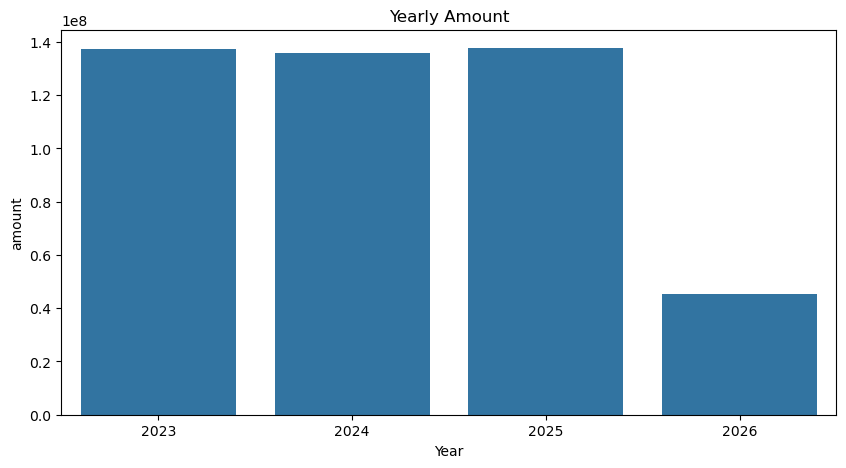

In [23]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=yoy,
    x='Year',
    y='amount'
)

plt.title("Yearly Amount")
plt.show()

# Monthly Transaction Trend

In [24]:
monthly = df.groupby(
    ['Year','Month']
)['amount'].sum().reset_index()

monthly.head()

,Year,Month,amount
0,2023,April,11617802.44
1,2023,August,11147689.67
2,2023,December,12046806.23
3,2023,February,10426699.36
4,2023,January,11372405.28


# Line Chart - Amount by Month

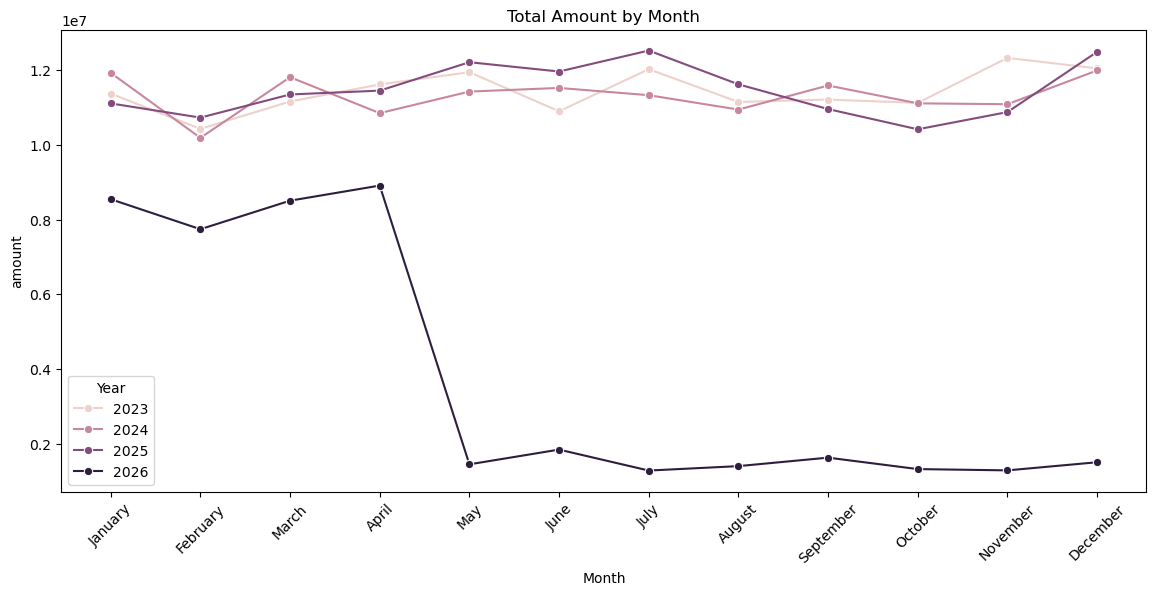

In [25]:
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly['Month'] = pd.Categorical(
    monthly['Month'],
    categories=month_order,
    ordered=True
)

monthly = monthly.sort_values(['Year','Month'])

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly,
    x='Month',
    y='amount',
    hue='Year',
    marker='o'
)

plt.xticks(rotation=45)
plt.title("Total Amount by Month")
plt.show()

# Transaction Status Analysis

In [26]:
status = df.groupby(
    'transaction_status'
)['amount'].sum().reset_index()

status

,transaction_status,amount
0,Failed,4.752361e+07
1,Pending,1.906771e+07
2,Success,3.895502e+08


# Donut Chart - Status

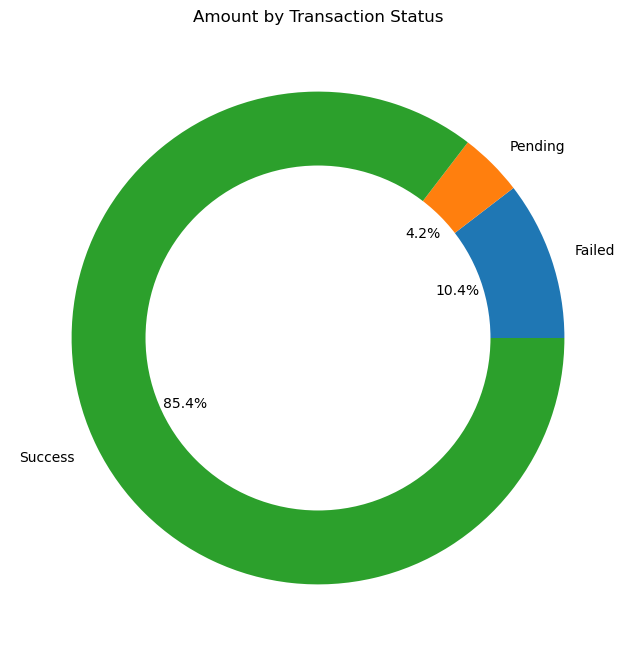

In [27]:
plt.figure(figsize=(8,8))

plt.pie(
    status['amount'],
    labels=status['transaction_status'],
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0),0.70,fc='white')

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Amount by Transaction Status")
plt.show()

# Customer Segment Analysis

In [28]:
segment = df.groupby(
    'customer_segment'
)['amount'].sum().reset_index()

segment = segment.sort_values(
    'amount',
    ascending=False
)

segment

,customer_segment,amount
2,Retail,2.483492e+08
1,Premium,8.448726e+07
3,SME,7.199629e+07
0,Corporate,3.085770e+07
4,Wealth,2.045105e+07


# Bar Chart - Customer Segment

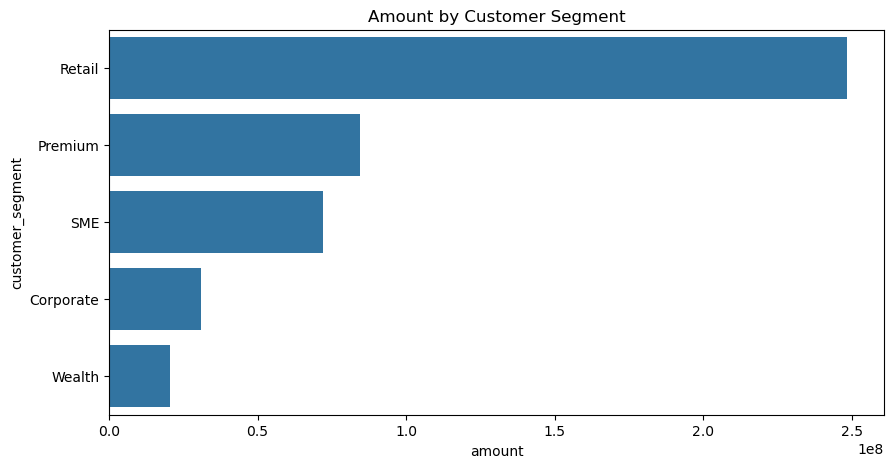

In [29]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=segment,
    x='amount',
    y='customer_segment'
)

plt.title("Amount by Customer Segment")
plt.show()

# State Analysis

In [30]:
state = df.groupby(
    'state'
)['amount'].sum().reset_index()

state = state.sort_values(
    'amount',
    ascending=False
)

state.head(10)

,state,amount
7,Maharashtra,68333921.00
4,Karnataka,52899083.03
2,Gujarat,50088655.72
9,Tamil Nadu,44936321.95
11,Uttar Pradesh,43632577.72
6,Madhya Pradesh,41037897.40
3,Haryana,25718386.68
5,Kerala,24262960.50
1,Delhi,23490597.31
12,West Bengal,22288749.07


# Top States Chart

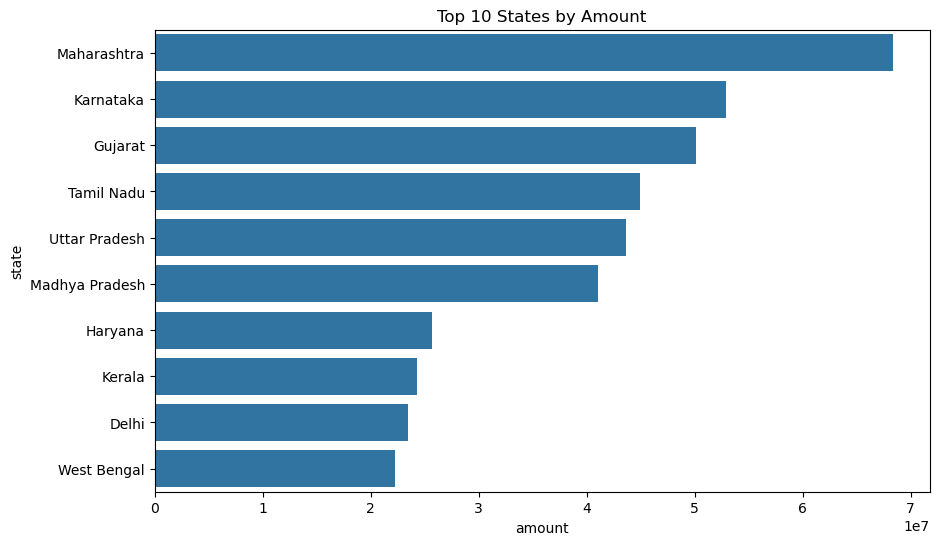

In [31]:
top_states = state.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_states,
    x='amount',
    y='state'
)

plt.title("Top 10 States by Amount")
plt.show()

# Transaction Type Analysis

In [32]:
transaction_type = df.groupby(
    'transaction_type'
).agg({
    'amount':'sum',
    'fee_amount':'sum',
    'tax_amount':'sum',
    'transaction_id':'count'
}).reset_index()

transaction_type.columns = [
    'Transaction Type',
    'Amount',
    'Fee',
    'Tax',
    'Transactions'
]

transaction_type

,Transaction Type,Amount,Fee,Tax,Transactions
0,Bill Payment,2.177101e+07,33391.40,6011.20,4310
1,Card Payment,2.687181e+07,43274.61,7781.75,5329
2,Deposit,6.882470e+07,113153.77,20366.94,4970
3,Fee Charge,1.749251e+06,2925.52,521.91,3640
4,Interest Credit,9.156504e+06,14625.82,2632.31,4017
5,Investment,4.919412e+07,80488.29,14487.76,3568
6,Loan EMI,1.311474e+08,204727.67,36884.78,9140
7,Refund,5.182970e+06,8060.77,1446.26,2337
8,Transfer,1.208539e+08,193402.30,34813.75,8479
9,Withdrawal,2.138987e+07,33392.39,6005.75,4279


# Heatmap Matrix

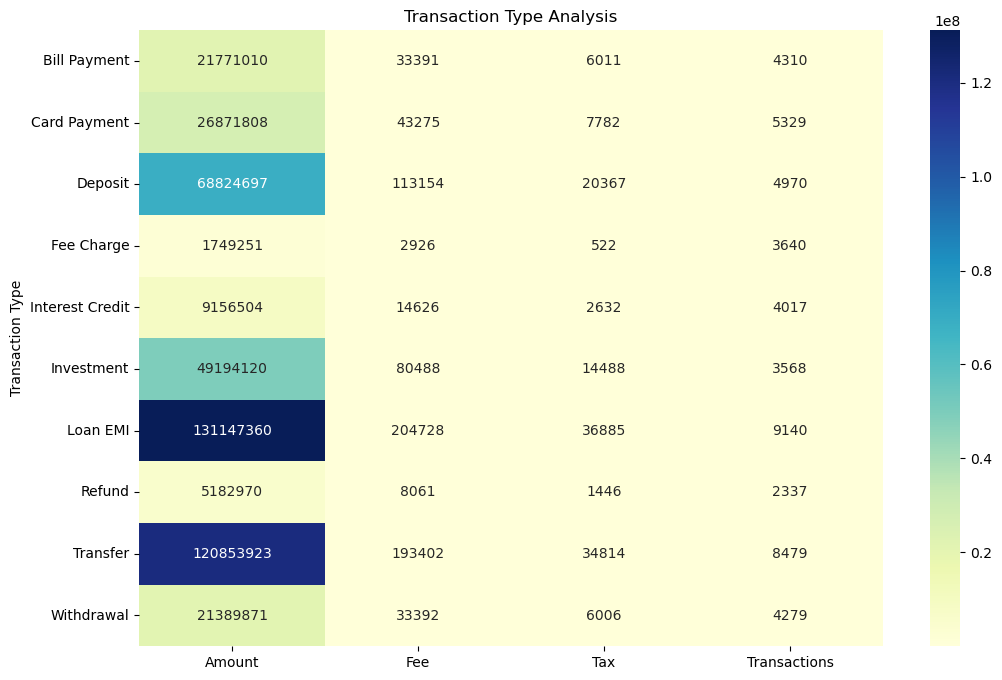

In [33]:
heatmap_data = transaction_type.set_index(
    'Transaction Type'
)

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title("Transaction Type Analysis")
plt.show()

# Gender Analysis

In [34]:
gender = df.groupby(
    'gender'
)['amount'].sum().reset_index()

gender

,gender,amount
0,Female,2.359701e+08
1,Male,2.201714e+08


# Gender Donut Chart

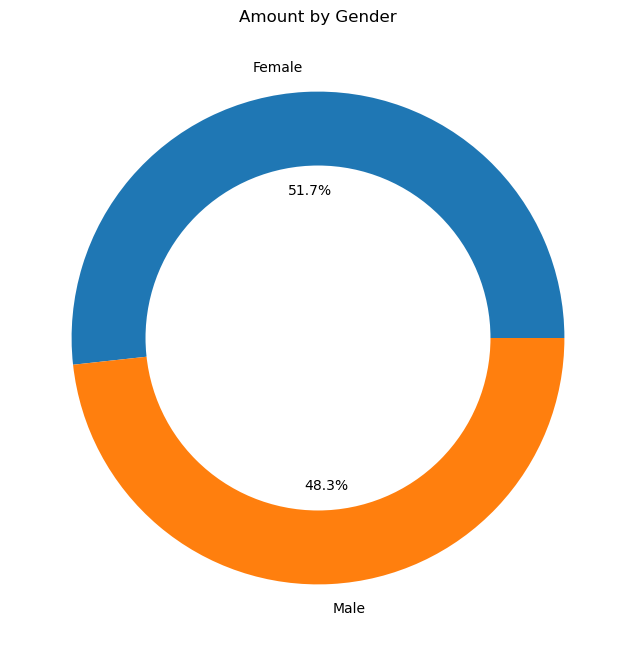

In [35]:
plt.figure(figsize=(8,8))

plt.pie(
    gender['amount'],
    labels=gender['gender'],
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0),0.70,fc='white')

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Amount by Gender")
plt.show()

# Occupation Analysis

occupation = df.groupby(
    'occupation'
)['amount'].sum().reset_index()

occupation = occupation.sort_values(
    'amount',
    ascending=False
)

occupation

# Occupation Chart

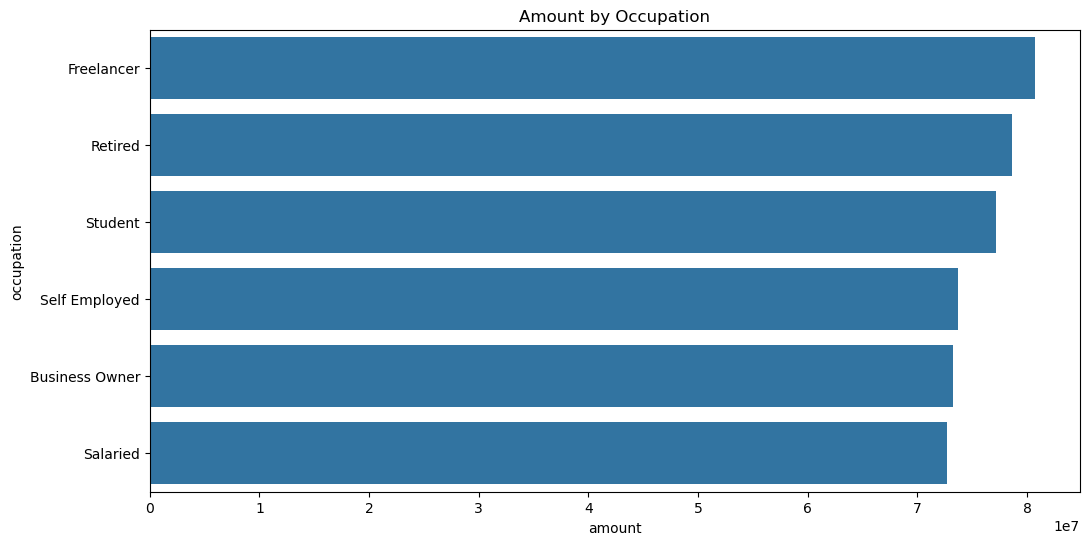

In [37]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=occupation,
    x='amount',
    y='occupation'
)

plt.title("Amount by Occupation")
plt.show()

# Top 20 Customers

In [38]:
top_customers = df.groupby(
    ['customer_id','fisrt_name']
)['amount'].sum().reset_index()

top_customers = top_customers.sort_values(
    'amount',
    ascending=False
).head(20)

top_customers

,customer_id,fisrt_name,amount
2979,C03734,Krishna,607366.67
3112,C03896,Vihaan,595663.43
51,C00069,Amit,587842.41
3612,C04524,Ishaan,545285.54
3363,C04201,Diya,518306.99
3726,C04671,Kiara,514772.27
1094,C01375,Rahul,497686.87
1707,C02133,Myra,495012.28
1849,C02313,Anika,472525.31
3243,C04059,Kabir,470414.75


# Fraud Analysis

In [39]:
fraud = df.groupby(
    'is_fraud'
)['amount'].sum().reset_index()

fraud

,is_fraud,amount
0,No,4.501579e+08
1,Yes,5.983627e+06


In [40]:
# Remove duplicate rows if any
df = df.drop_duplicates()
 

In [41]:
# Save cleaned dataset
df.to_csv(
    r"C:\Users\Admin\Documents\Deepak Documents\PROJECTS\Financial Analysis Dashboard\Python Analysis\finance_merged_cleaned.csv",
    index=False
)

print("Cleaned merged dataset saved successfully")

Cleaned merged dataset saved successfully


In [43]:
saved_df = pd.read_csv(
    r"C:\Users\Admin\Documents\Deepak Documents\PROJECTS\Financial Analysis Dashboard\Python Analysis\finance_merged_cleaned.csv"
)

saved_df.head()

,transaction_id,transaction_date,account_id,customer_id,transaction_type,channel,merchant_category,amount,fee_amount,tax_amount,currency,transaction_status,is_fraud,risk_score,reference_no,Year,Month,fisrt_name,second_name,gender,date_of_birth,city,state,occupation,customer_segment,annual_income,join_date
0,T00000001,2025-02-21,A001795,C00629,Investment,Mobile App,Food Delivery,24721.24,123.61,22.25,INR,Success,No,63,REF8835851139,2025,February,Neha,Desai,Female,16-07-1994,Coimbatore,Tamil Nadu,Salaried,Premium,"₹1,521,243.86",2025-03-28
1,T00000002,2023-01-28,A004859,C02038,Transfer,UPI,Groceries,18711.77,93.56,16.84,INR,Success,No,21,REF9409811139,2023,January,Aarav,Chopra,Female,18-12-1989,Bengaluru,Karnataka,Freelancer,Retail,"₹365,023.04",2021-01-15
2,T00000003,2024-06-25,A003081,C00652,Transfer,Net Banking,Groceries,45865.90,0.00,0.00,INR,Success,No,25,REF1704628312,2024,June,Sneha,Verma,Male,24-06-1988,Chandigarh,Chandigarh,Retired,Wealth,"₹1,973,706.42",NaN
3,T00000004,2025-02-20,A004122,C01357,Withdrawal,Auto Debit,Salary,4310.91,14.52,0.78,INR,Failed,No,43,REF3937614748,2025,February,Pooja,Reddy,Male,24-09-2002,Pune,Maharashtra,Self Employed,Corporate,"₹555,476.53",2020-03-15
4,T00000005,2024-06-08,A004150,C02547,Deposit,Branch,Shopping,11646.45,0.00,0.00,INR,Success,No,5,REF5855288886,2024,June,Reyansh,Chopra,Female,22-09-2004,Mysuru,Karnataka,Self Employed,SME,"₹1,107,795.82",2023-09-25
